### Equipo
* Rocío Sánchez Solórzano 	2043109	IB
* Alisson Michelle Sepúlveda Torres	2115253 IB
* Benito Woo Zozaya	2177866	IB
* David Palma Cabañez	2177805	IB


In [59]:
#Librerias
import kagglehub
import numpy as np
import kagglehub
import cv2
import os
%pip install pydicom
import pydicom
from google.colab.patches import cv_imshow
from matplotlib import pyplot as plt
from google.colab import files
import widgetsnbextension
import ipywidgets as widgets
from IPython.display import display

In [72]:
#1 Cargar imagenes
def cargar_imagenes():
  global dicom_image, dicom_image_high
  uploaded = files.upload()
  image_path = list(uploaded.keys())[0]
  print("Path to dataset files:", image_path)
  dicom_data = pydicom.dcmread(image_path)
  #normalizamos la imagen para pasarla de 16 bits a 8 bits
  dicom_image = cv2.normalize(dicom_data.pixel_array, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
  dicom_image_high = cv2.normalize(dicom_data.pixel_array, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_32F)
cargar_imagenes()


Saving Rx_torso.dcm to Rx_torso (2).dcm
Path to dataset files: Rx_torso (2).dcm


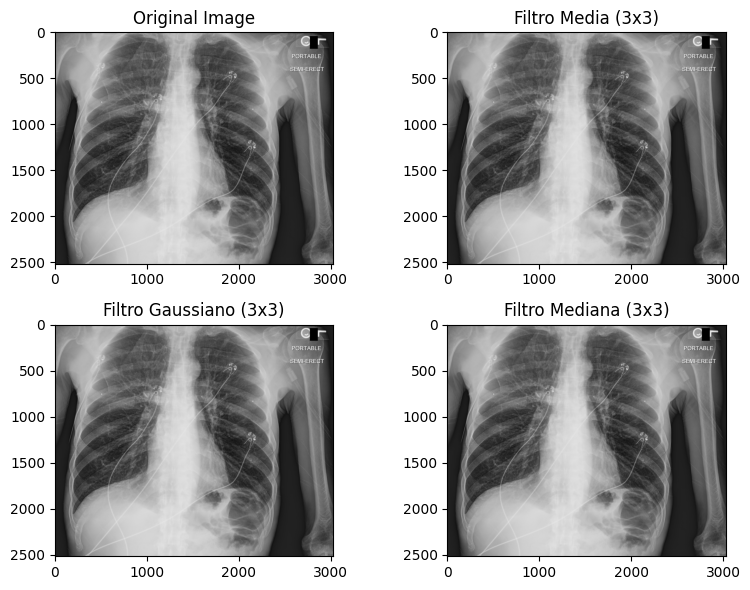

In [74]:
#Filtros paso bajo (media, gaussiano, mediana), usando diferentes tamaños de kernel (3x3, 5x5, 11x11).
def filtro_pasa_baja():
  global dicom_image, dicom_image_high
  kernel = 3
  media_filtered = cv2.blur(dicom_image, (kernel, kernel))
  gaussian_filtered = cv2.GaussianBlur(dicom_image_high, (kernel, kernel), 0)
  median_filtered = cv2.medianBlur(dicom_image, kernel)

  plt.figure(figsize=(8, 6))
  plt.subplot(2, 2, 1)
  plt.imshow(dicom_image, cmap='gray')
  plt.title('Original Image')
  plt.subplot(2, 2, 2)
  plt.imshow(media_filtered, cmap='gray')
  plt.title(f'Filtro Media ({kernel}x{kernel})')
  plt.subplot(2, 2, 3)
  plt.imshow(gaussian_filtered, cmap='gray')
  plt.title(f'Filtro Gaussiano ({kernel}x{kernel})')
  plt.subplot(2, 2, 4)
  plt.imshow(median_filtered, cmap='gray')
  plt.title(f'Filtro Mediana ({kernel}x{kernel})')

  plt.tight_layout()
  plt.show()
filtro_pasa_baja()

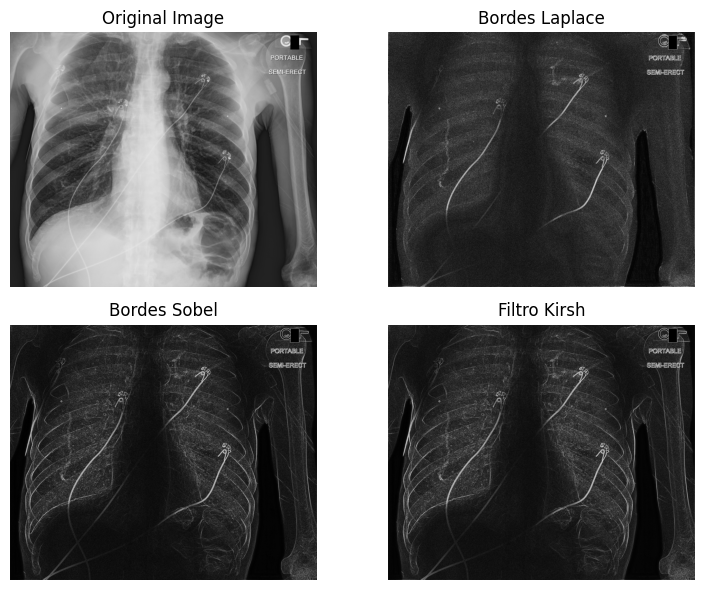

In [75]:
#Detección de Bordes
def deteccion_bordes():
  global dicom_image, dicom_image_high
  img_laplace = cv2.Laplacian(dicom_image_high, cv2.CV_32F, ksize=3)

  sobelx = cv2.Sobel(dicom_image_high, cv2.CV_32F, 1, 0, ksize=3)
  sobely = cv2.Sobel(dicom_image_high, cv2.CV_32F, 0, 1, ksize=3)
  abs_sobelx = np.absolute(sobelx)
  abs_sobely = np.absolute(sobely)
  img_sobel = cv2.addWeighted(abs_sobelx, 0.5, abs_sobely, 0.5, 0)

  kernels_kirsch = [
      np.array([[ 5,  5,  5], [-3,  0, -3], [-3, -3, -3]]), # N
      np.array([[-3,  5,  5], [-3,  0,  5], [-3, -3, -3]]), # NE
      np.array([[-3, -3,  5], [-3,  0,  5], [-3, -3,  5]]), # E
      np.array([[-3, -3, -3], [-3,  0,  5], [-3,  5,  5]]), # SE
      np.array([[-3, -3, -3], [-3,  0, -3], [ 5,  5,  5]]), # S
      np.array([[-3, -3, -3], [ 5,  0, -3], [ 5,  5, -3]]), # SW
      np.array([[ 5, -3, -3], [ 5,  0, -3], [ 5, -3, -3]]), # W
      np.array([[ 5,  5, -3], [ 5,  0, -3], [-3, -3, -3]])  # NW
  ]

  # Inicializamos la matriz de acumulación en float32 del mismo tamaño que la imagen
  img_kirsch = np.zeros_like(dicom_image_high)

  # Aplicamos cada uno de los 8 filtros y guardamos el gradiente máximo por píxel
  for k in kernels_kirsch:
      # Usamos cv2.CV_32F para no perder precisión durante las convoluciones
      resultado = cv2.filter2D(dicom_image_high, cv2.CV_32F, k)
      img_kirsch = np.maximum(img_kirsch, resultado)

  laplace_vis = normalizar_por_percentil(np.absolute(img_laplace), percentil=99.5)
  sobel_vis = normalizar_por_percentil(img_sobel, percentil=99.5)
  kirsch_vis = normalizar_por_percentil(img_kirsch, percentil=99.5)

  plt.figure(figsize=(8, 6))


  plt.subplot(2, 2, 1)
  plt.imshow(dicom_image, cmap='gray')
  plt.title('Original Image')
  plt.axis('off')
  plt.subplot(2, 2, 2)
  plt.imshow(laplace_vis, cmap='gray')
  plt.title(f'Bordes Laplace')
  plt.axis('off')
  plt.subplot(2, 2, 3)
  plt.imshow(sobel_vis, cmap='gray')
  plt.title(f'Bordes Sobel')
  plt.axis('off')
  plt.subplot(2, 2, 4)
  plt.imshow(kirsch_vis, cmap='gray')
  plt.title(f'Filtro Kirsh')
  plt.axis('off')

  plt.tight_layout()
  plt.show()


def normalizar_por_percentil(imagen_borde, percentil=99.5): #se utiliza para evitar el contraste de la esquina
  limite_superior = np.percentile(imagen_borde, percentil)
  imagen_recortada = np.clip(imagen_borde, 0, limite_superior)
  return cv2.normalize(imagen_recortada, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
deteccion_bordes()

In [76]:
slider = widgets.IntSlider(min=0, max=255, step=1, value=20, description='Umbral para LoG:', continuous_update=False)

def LoG (threshold):
#Mascara personalizada, utilizaremos el filtro LoG, Laplacian of Gaussian para esto
  global dicom_image, dicom_image_high
  kernel_gauss = 7 #cuanto más alto el tamaño del kernel más ruido limpia
  kernel_laplace = 3
  gaussian_filtered = cv2.GaussianBlur(dicom_image_high, (kernel_gauss, kernel_gauss), 0)
  img_laplace = cv2.Laplacian(gaussian_filtered, cv2.CV_32F, kernel_laplace)
  img_LoG = normalizar_por_percentil(np.absolute(img_laplace), percentil=99.5)

  _, binary_segmentation = cv2.threshold(img_LoG, threshold, 255, cv2.THRESH_BINARY)
  img= cv2.bitwise_and(dicom_image, dicom_image, mask=binary_segmentation)

  plt.figure(figsize=(15, 5))

  plt.subplot(1, 2, 1)
  plt.imshow(dicom_image, cmap='gray')
  plt.title('Original Image')
  plt.axis('off')
  plt.subplot(1, 2, 2)
  plt.imshow(img, cmap='gray')
  plt.title(f'Laplacian of Gaussian')
  plt.axis('off')
  plt.tight_layout()
  plt.show()


widgets.interactive(LoG, threshold=slider)
#para el torax entre 20 y 30 en el umbral se ve bien

interactive(children=(IntSlider(value=20, continuous_update=False, description='Umbral para LoG:', max=255), O…

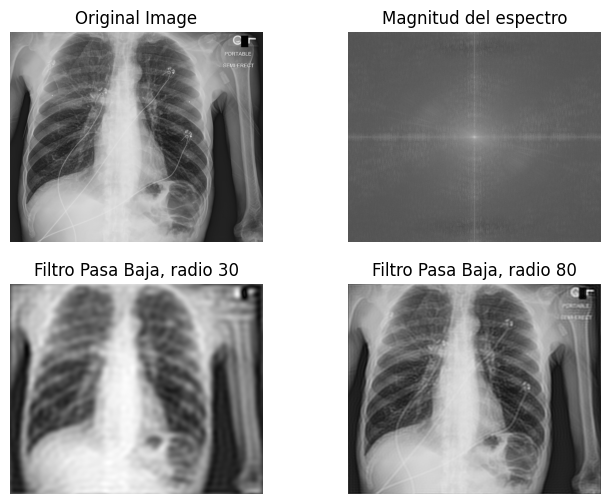

In [77]:
def trans_fourier():
  global dicom_image, fshift, magnitude_spectrum
  f = np.fft.fft2(dicom_image)
  fshift = np.fft.fftshift(f)
  magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

def pasa_baja_fourier(r1, r2):
  #Dominio de la frecuencia
  global dicom_image, dicom_image_high, fshift, magnitude_spectrum
  rows, cols = dicom_image.shape
  crow, ccol = rows // 2 , cols // 2

  plt.figure(figsize=(8, 6))

  plt.subplot(2, 2, 1)
  plt.imshow(dicom_image, cmap='gray')
  plt.title('Original Image')
  plt.axis('off')
  plt.subplot(2, 2, 2)
  plt.imshow(magnitude_spectrum, cmap='gray')
  plt.title('Magnitud del espectro')
  plt.axis('off')

  radio = [r1, r2]
  i=3
  for r in radio:
    # Crear máscara circular
    mask = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), r, 1, thickness=-1)

    # Aplicar la máscara al espectro
    fshift_filtered = fshift * mask

    # Transformada inversa
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    plt.subplot(2, 2, i)
    plt.imshow(img_back, cmap='gray')
    plt.title(f'Filtro Pasa Baja, radio {r}')
    plt.axis('off')
    i+=1

trans_fourier()
pasa_baja_fourier(30,80)

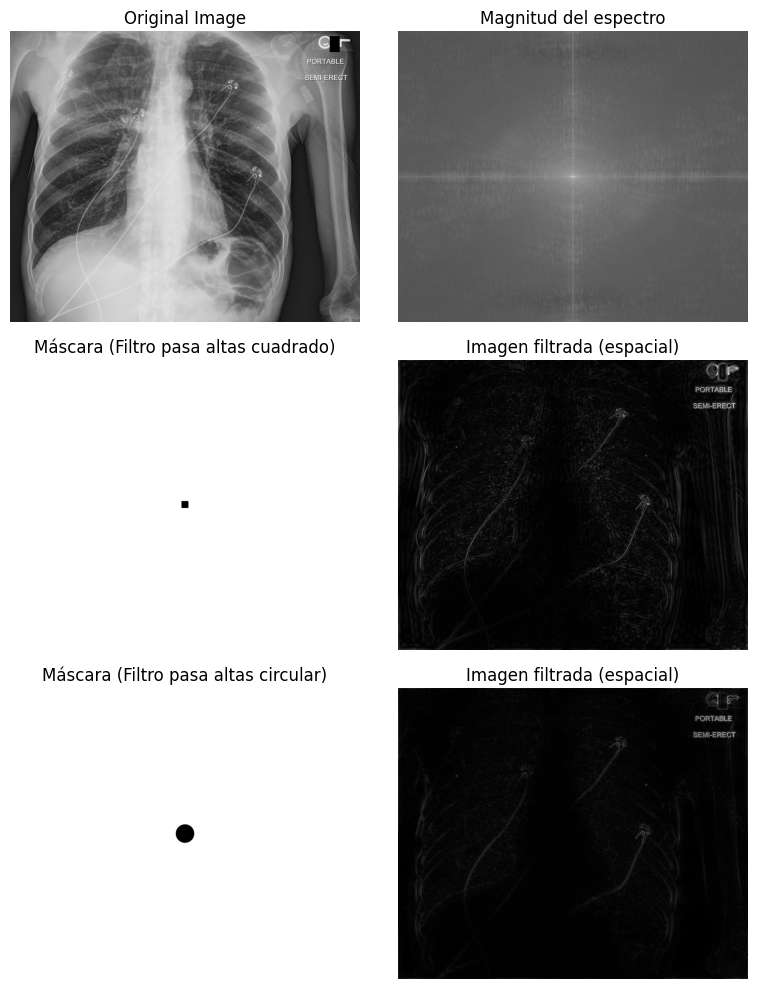

In [78]:
def pasa_alta_fourier():
  global dicom_image, fshift, magnitude_spectrum

  #Filtro pasa altas: máscara cuadrada en el centro
  rows, cols = dicom_image.shape
  crow, ccol = rows // 2 , cols // 2
  size = 60  # Tamaño del cuadrado a eliminar (bajas frecuencias)

  # Crear máscara con unos, luego poner a cero la región central
  mask_square = np.ones((rows, cols), np.uint8)
  mask_square[crow - size//2 : crow + size//2, ccol - size//2 : ccol + size//2] = 0

  r=80
  mask_circle = np.ones((rows, cols), np.uint8)
  cv2.circle(mask_circle, (ccol, crow), r, 0, thickness=-1)

  # Aplicar la máscara
  fshift_filtered_square = fshift * mask_square
  fshift_filtered_circle = fshift * mask_circle

  # Transformada inversa cuadrado
  f_ishift_square = np.fft.ifftshift(fshift_filtered_square)
  img_square = np.fft.ifft2(f_ishift_square)
  img_square = np.abs(img_square)
  # Transformada inversa circulo
  f_ishift_circle = np.fft.ifftshift(fshift_filtered_circle)
  img_circle = np.fft.ifft2(f_ishift_circle)
  img_circle = np.abs(img_circle)

  # Mostrar resultados
  plt.figure(figsize=(8, 10))
  plt.subplot(3, 2, 1)
  plt.imshow(dicom_image, cmap='gray')
  plt.title('Original Image')
  plt.axis('off')

  plt.subplot(3, 2, 2)
  plt.imshow(magnitude_spectrum, cmap='gray')
  plt.title('Magnitud del espectro')
  plt.axis('off')

  plt.subplot(3, 2, 3)
  plt.imshow(mask_square, cmap='gray')
  plt.title('Máscara (Filtro pasa altas cuadrado)')
  plt.axis('off')

  plt.subplot(3, 2, 4)
  plt.imshow(img_square, cmap='gray')
  plt.title('Imagen filtrada (espacial)')
  plt.axis('off')

  plt.subplot(3, 2, 5)
  plt.imshow(mask_circle, cmap='gray')
  plt.title('Máscara (Filtro pasa altas circular)')
  plt.axis('off')

  plt.subplot(3, 2, 6)
  plt.imshow(img_circle, cmap='gray')
  plt.title('Imagen filtrada (espacial)')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

pasa_alta_fourier()

Saving Mammography.dcm to Mammography (2).dcm
Path to dataset files: Mammography (2).dcm


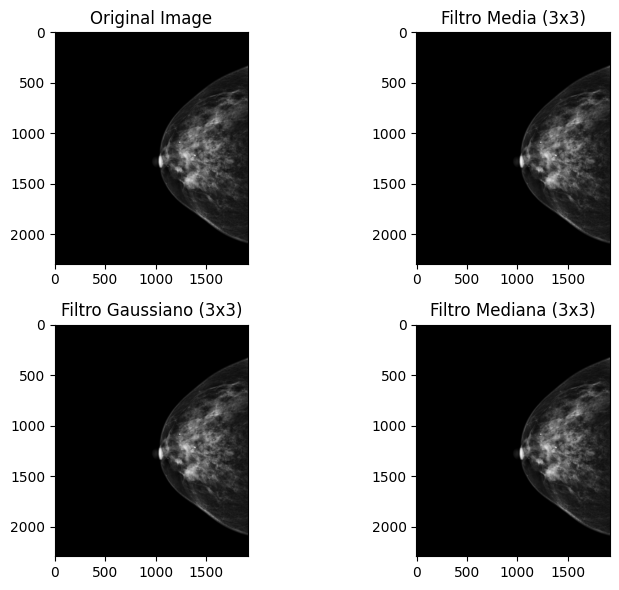

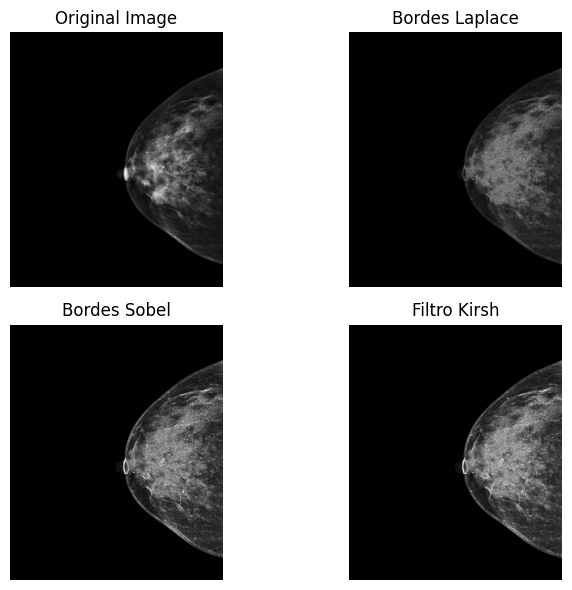

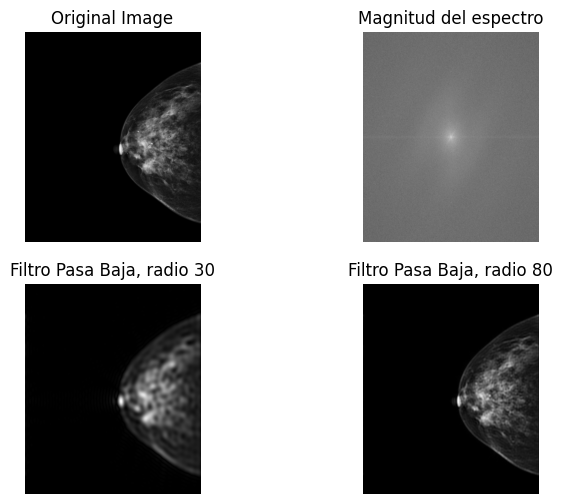

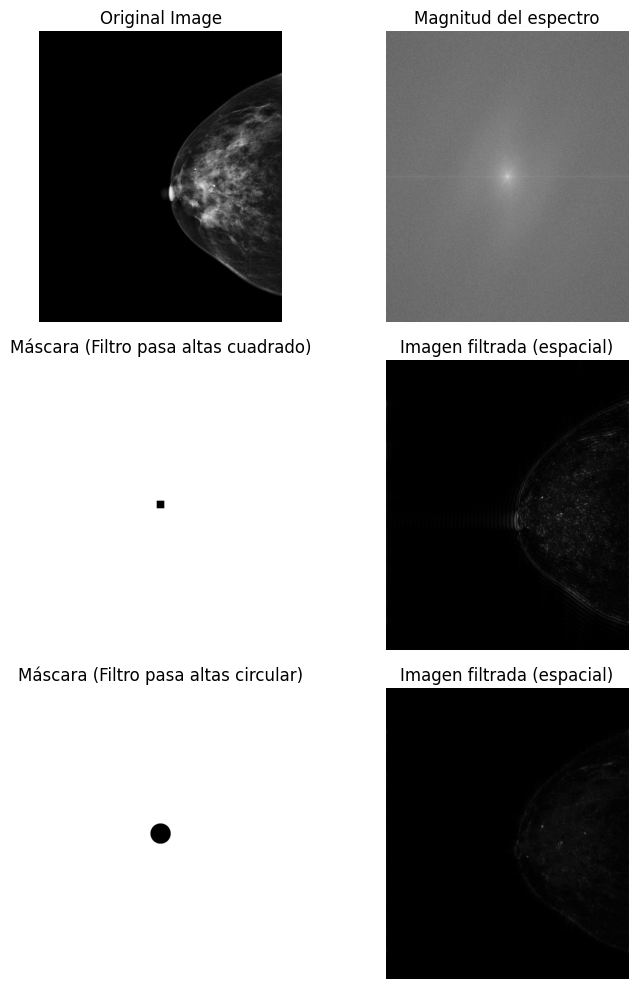

In [79]:
#para llamar la segunda imagen vamos a llamar las funciones nuevamente

def segunda_imagen():
  global dicom_image, dicom_image_high
  dicom_image = None
  dicom_image_high = None
  cargar_imagenes()
  filtro_pasa_baja()
  deteccion_bordes()
  normalizar_por_percentil(dicom_image_high, percentil=99.5)
  trans_fourier()
  pasa_baja_fourier(30,80)
  pasa_alta_fourier()
segunda_imagen()